In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import os
os.environ["SYNTHCITY_DEVICE"] = "cpu"
import random

import tapas
from tapas.attacks.set_classifiers import RandomTargetedQueryFeature
from utils.my_attack import MyAttack
#from utils.benchmark_pipeline import BenchmarkPipeline
from utils.benchmark_metric import AUCMetric
from utils.tapas.tapas_data_processors import AdultDataProcessor

from utils.basegenerators import BenchmarkGenerator, ReprosynGenerator, Raw

from utils.customgenerators import SynthcityGenerator, SDVGenerator
#from utils.customgenerators import PrivpgdGenerator

from reprosyn.methods import DS_PRIVBAYES
from reprosyn.methods import DS_BAYNET
from sdv.single_table import GaussianCopulaSynthesizer

# For Marginal-based methods
project_root = Path().resolve()  # This is where the notebook is running from

'''
pgd_path = project_root / "libs/private-pgd/src"
sys.path.append(str(pgd_path))
from inference.dataset import Dataset
from inference.domain import Domain
'''

pgd_path = project_root / "libs/private-pgd/data"
sys.path.append(str(pgd_path))
from data_handler import DataHandler
from mechanisms.kway import KWay
from inference.privpgd.inference import AdvancedSlicedInference
from inference.pgm.inference import FactoredInference
from mechanisms.aim import AIM
from mechanisms.mst import MST
#from inference.dataset import Dataset
#from inference.evaluation import Evaluator

'''

pgd_path = project_root / "libs/private-pgd/examples"
sys.path.append(str(pgd_path))
from utils_examples import flatten_dict
from mechanisms.utils_mechanisms import generate_all_kway_workload
'''

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ModuleNotFoundError: No module named 'autodp'

In [4]:
pip show privpgd

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install gower

In [7]:
!pip check

hydra-optuna-sweeper 1.2.0 has requirement optuna<3.0.0,>=2.10.0, but you have optuna 4.3.0.
lifelines 0.29.0 has requirement pandas>=2.1, but you have pandas 1.5.3.
synthcity 0.2.11 has requirement pandas>=2.1, but you have pandas 1.5.3.
tapas 1.0.0 has requirement setuptools<66.0.0,>=65.5.0, but you have setuptools 80.8.0.
xgbse 0.3.3 has requirement pandas<3.0.0,>=2.2.0, but you have pandas 1.5.3.


In [5]:
from synthcity.plugins.generic import plugin_great
print(plugin_great.plugin)

NameError: name 'Replicate' is not defined

In [6]:

gen = PrivpgdGenerator(generation_engine=AdvancedSlicedInference, mechanism=KWay,label="privpgd", num_bins = 2, deg_workload = 2, **{"epsilon": 1.0, "delta":1e-5, "iters": 70, "eval_particles": True})


In [4]:
gen = PrivpgdGenerator(generation_engine=AdvancedSlicedInference, mechanism=KWay,label="privpgd", num_bins = 2, deg_workload = 2)


In [5]:
#kills kernel 
gen5 = PrivpgdGenerator(generation_engine=FactoredInference, mechanism=MST, label="mst+pgm", num_bins = 2, deg_workload = 2, **{"iters":50} )

In [6]:
gen6 = PrivpgdGenerator(generation_engine=FactoredInference, mechanism=AIM, label="aim+pgm", num_bins = 2, deg_workload = 2, **{"iters":50} )

In [5]:
gen1 = ReprosynGenerator(DS_PRIVBAYES, label="PrivBayes", epsilon=1.0)
repr(gen1)

'PrivBayes_epsilon=1.0'

In [8]:
gen2 = SynthcityGenerator("uniform_sampler", label="uniform_sampler")
repr(gen2)

'uniform_sampler_random_state=42'

In [9]:
gen3 = Raw()
repr(gen3)

'Raw'

In [10]:
gen4 = SDVGenerator(GaussianCopulaSynthesizer, label="GaussianCopulaSynthesizer")
repr(gen4)

'GaussianCopulaSynthesizer'

In [11]:
# !pip install tf_keras

45
estimating categorical probs
estimating approx kdes(histogram)
[0.0]
Attacking : PrivBayes_epsilon=1.0
Generated datasest of PrivBayes stored at :data/generated_datasets/PrivBayes_epsilon=1.0.pkl
COMPLEXITY:  2


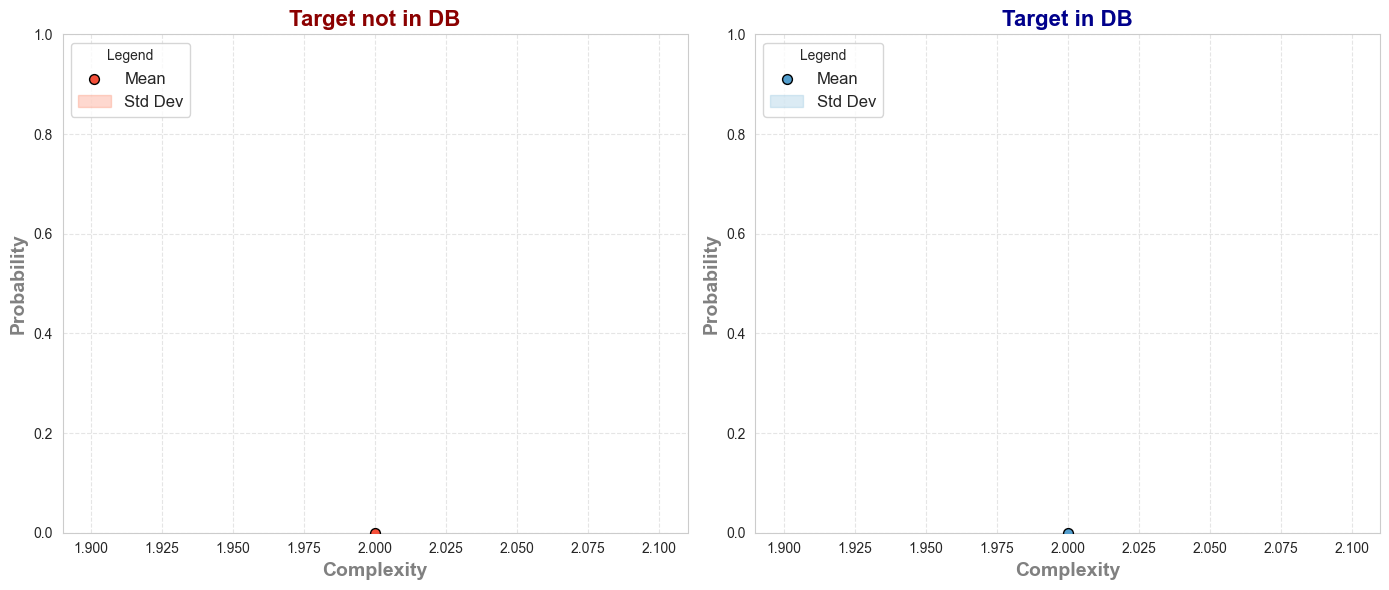

Attacking : privpgd_deg_workload=2_delta=1e-05_epsilon=1.0_eval_particles=True_iters=70_num_bins=2


In [ ]:
#TEST PIPELINE
data = tapas.datasets.TabularDataset.read("data/adult")
data = AdultDataProcessor.process_tapas_tabulardataset(data)
data = data.sample(frac = 0.001)  #downsample the data 
print(len(data.data))
ind = [int(random.random() * len(data.data))]

target_record = data.get_records(ind)
data.drop_records(ind, in_place=True)

attack = MyAttack(100, features=RandomTargetedQueryFeature(target_record,4,2000))


pipeline = BenchmarkPipeline(data, attack, [gen1, gen], target_record=target_record)
benchmarking_metric = AUCMetric([0,0.17,0.33,0.50,0.67,0.83])
pipeline.run([2], 10, 2, plot_style = "double", benchmarking_metric=benchmarking_metric)